In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
with open('/home/argon/Projects/Ilker/gxsim/CRAB/data/CRAB_Profiles_Rotated.csv') as csvfile:
    lines = csvfile.readlines()


In [3]:
x=np.array([])
y=np.array([])
z=np.array([])
t=np.array([])
ph=np.array([])

In [4]:
counter=0
for line in lines:
    linesplited=line.split(',')
    x=np.append(x,float(linesplited[1].strip()))
    y=np.append(y,float(linesplited[2].strip()))
    z=np.append(z,float(linesplited[3].strip()))
    ph=np.append(ph,float(linesplited[4].strip()))
    counter+=1
    if(counter==50000):
        break

In [5]:
def ELDistribution(x,a,b,m,k,offset):
    #return a*np.exp((-x*b)+k)-m*x+offset
    return a*np.exp((-x*b)+k)-m*x+offset

from scipy.optimize import curve_fit

In [6]:
initials=(3600,20,+1e3,-0.68,-10)
popt,pcov=curve_fit(ELDistribution,z,ph,p0=initials,maxfev=20000)

In [7]:
initials=(1,20,+1,-0.68,-10)
popt,pcov=curve_fit(ELDistribution,z,ph,p0=initials,maxfev=20000)

/tmp/argon/opticks/ipykernel_2981250/720952671.py:3: RuntimeWarning: overflow encountered in exp
  return a*np.exp((-x*b)+k)-m*x+offset


In [8]:
print(popt)

[ 7.30869780e-19  7.54842379e+01  3.44047970e+03 -6.13124065e+00
  7.27100103e+01]


<Axes: xlabel='z(cm)', ylabel='Photons'>

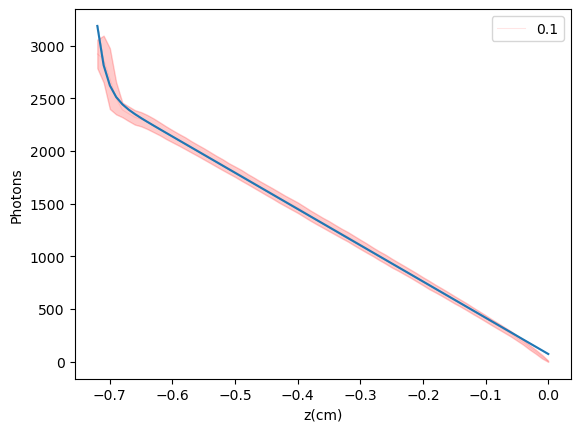

In [9]:
import seaborn as sn
df={"z(cm)":z,"Photons":ph}
sn.lineplot(data=df,x="z(cm)",y="Photons",errorbar='sd',size=0.1,color="red",alpha=0.1)
sn.lineplot(x=z,y=ELDistribution(z,*popt))
#plt.ylabel("Percentage")

In [10]:
np.sum(ELDistribution(z,*popt))

71016794.48223151

In [11]:
print(df["Photons"])

[  0.  105.  108.1 ... 706.5 707.4 712.2]


In [12]:
import pandas as pd
df = pd.DataFrame(data=df)

In [13]:
newdf=df.groupby("z(cm)").agg(['mean','std'])


In [14]:
percent=newdf["Photons"]["std"]/newdf["Photons"]["mean"]
mean=np.array((newdf["Photons"]["mean"]/newdf["Photons"]["mean"].sum()).values.tolist())
stds=np.array(percent.values.tolist())*mean
dictt={"z(cm)":np.array(percent.keys()),"mean":mean,"std":stds}

In [15]:
dictt

{'z(cm)': array([-0.72, -0.71, -0.7 , -0.69, -0.68, -0.67, -0.66, -0.65, -0.64,
        -0.63, -0.62, -0.61, -0.6 , -0.59, -0.58, -0.57, -0.56, -0.55,
        -0.54, -0.53, -0.52, -0.51, -0.5 , -0.49, -0.48, -0.47, -0.46,
        -0.45, -0.44, -0.43, -0.42, -0.41, -0.4 , -0.39, -0.38, -0.37,
        -0.36, -0.35, -0.34, -0.33, -0.32, -0.31, -0.3 , -0.29, -0.28,
        -0.27, -0.26, -0.25, -0.24, -0.23, -0.22, -0.21, -0.2 , -0.19,
        -0.18, -0.17, -0.16, -0.15, -0.14, -0.13, -0.12, -0.11, -0.1 ,
        -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03, -0.02, -0.01,
         0.  ]),
 'mean': array([3.02315087e-02, 2.97261378e-02, 2.78044924e-02, 2.58806394e-02,
        2.47273724e-02, 2.43543165e-02, 2.39956212e-02, 2.38139418e-02,
        2.35362737e-02, 2.32118639e-02, 2.28650174e-02, 2.24866296e-02,
        2.21411113e-02, 2.18065441e-02, 2.14723439e-02, 2.11066555e-02,
        2.07636658e-02, 2.04180792e-02, 2.00578459e-02, 1.96942409e-02,
        1.93496321e-02, 1.89861760e-02

In [21]:
with open("/home/argon/Projects/Ilker/NewNexus/data/ELProfile.txt","w") as f:
    f.write("Probability distribution of photons as a function of distance z (cm)\n")
    f.write("z,prob\n")
    for i in range(0,len(dictt["z(cm)"])):
        zi=abs(round(dictt["z(cm)"][i],2))
        meani=round(dictt["mean"][i],4)
        f.write(f"{zi},{meani}\n")
f.close()        

In [ ]:
plt.figure(figsize=(6,5),dpi=300)
plt.title("CRAB Gain")
plt.hist2d(x,z,weights=ph,bins=200,label="CRAB Profile")
#plt.ylabel("Gap Distance(cm)")
#plt.xlabel("X(cm)")
plt.colorbar()
plt.show()
